In [193]:
import dotenv, os
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_openai import ChatOpenAI
import operator
from typing import Dict, List, Annotated, Literal
from tavily import TavilyClient
from langchain_community.tools import DuckDuckGoSearchResults, TavilySearchResults
from langchain.agents import create_agent
from langgraph_supervisor import create_supervisor
from langchain_core.tools import tool



In [171]:
dotenv.load_dotenv()

True

In [172]:
# step1: Define the base LLM
base_llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0.0, max_tokens=4000, request_timeout=120)

In [173]:
# Step 2: Define the SupervisorDecision model
class SupervisorDecision(BaseModel):
    """ Supervisor's routing decision - Must pick one of these options """
    next_agent : Literal['researcher', 'mathematician', 'final'] = Field(description = "Which worker shouldwork next or 'final' if enough information is gathered to produce the final answer.")

    reason : str = Field(description = "Reasoning behind the decision. This will be used to explain the decision to the user.")


In [174]:
# Step 3: Define the FinalAnswer model
class FinalAnswer(BaseModel):
    """ Final answer model """
    answer : str = Field(description = "Final answer to the user's question.")


# Math extractor 
class Math_string_extractor(BaseModel):
    """Extract Exact Mathametical Expresion from a String"""
    math_string : str = Field(description="Extract eaxact mathmetical expresion for calculation")

In [175]:
# Supervisor State

class SupervisorState(TypedDict):
    query: str
    history: Annotated[list, operator.add]
    final_answer: str

In [195]:
# Define the tools which will work inside of the worker nodes

# Calculator tool
@tool
def calculate(expression : str) -> str:
    """ Simple calculator tool that evaluates a mathematical expression. """
    try:
        return str(
            eval(expression, 
                 {"__builtins__": {}},
                   {}))
    except Exception as e:
        return f"Error: {e}"           # ← Galat expression ho toh error pakdo!





# Search Tool 
tavily_key= os.environ.get("TAVILY_API_KEY")
tavily_tool = TavilySearchResults( search_kwargs={"num_results": 2})

@tool
def web_search(query: str)-> str:
    """ Simple web search with Tavily tool"""

    output=[]

    try:
        search_result = tavily_tool.invoke(query)


        for i in search_result:


            output.append(f" Title : {i.get('title', 'No title')}")
            output.append(f" Content : {i.get('content', 'No snippet')}")
            output.append(f" URL : {i.get('url', 'No link')}")
    except Exception as e:
        print(f"Error {e}")

    if output:
        return "\n".join(output)
    







In [196]:
# Supervisor node

def supervisor_node(state: SupervisorState)->Command[Literal['researcher', 'mathematician', 'final']]:



# Done so far variable will have all the history what happned yet inside the application, like which worker worked if any web search result is generated then if the generated result is fine to give the answer etc

    done_so_far = "\n".join(
        state.get('history', [])
    ) or "Nothing Yet"


    struct_llm = base_llm.with_structured_output(SupervisorDecision)

    query = state['query']

    prompt = f""" 
                You are a supervisor manngaing 2 workers.\n

                - "researcher" : does a web search for the query asked by the user and gets the relavent part - recent news, upadted, flactual updates etc \n

                - "mathematician" : Dose calculation \n

            
                "Original Query" :\n {query}\n

                "Work completed so far" : \n 
                {done_so_far}\n


                Decide what should happen next. If you have enough infomration from worker done so far, for full answer of the original query choose 'final' 
            """
    
    decision : SupervisorDecision = struct_llm.invoke(prompt)

    print(f"🕴️Supervior - > Goto {decision.next_agent} | Resason {decision.reason}")
    
    

    return Command(
        goto=decision.next_agent, 
        update = {'history': [f'[Supervisor] decided to go {decision.next_agent} because of {decision.reason}']}
    )

In [211]:
#step 6 Worker Node

def research_node(state: SupervisorState)-> Command[Literal["supervisor"]]:
    print("🔎 Researcher Is working")

    result = web_search.invoke(state['query'])
    # print(result)

    return Command(
        goto='supervisor',
        update={'history': [
            f"[Researcher] {result}"
        ]}
    )


def math_node(state: SupervisorState)-> Command[Literal["supervisor"]]:
    print("📱 Mathametician is Working")


    extractor_exact_math_string = base_llm.with_structured_output(Math_string_extractor)

    prompt =f"""You are a Mathametical Expresion extractor. You need to provide the extracted result in a string from the given query

    Example : \n
    "What is the value of 10+20? -> '10 + 20'
    "What is the gdp of inid and what is 10*20? -> "10 * 20"

    Query: \n 
    {state['query']}

        """

    math_string = extractor_exact_math_string.invoke(prompt)





    result = calculate.invoke(math_string.math_string)


    return Command(
        goto='supervisor',
        update={'history': [
            f"[Mathameticain] {result}"
        ]}
    )

In [198]:
# Step 7 : Final Node

def final_node(state: SupervisorState)-> Command[Literal["__end__"]]:
    print("✍️ Generating Result")

    done_so_far = "\n".join(state['history'])

    final_llm_struct= base_llm.with_structured_output(FinalAnswer)

    prompt = f""" 

    Orginal Query : \n {state['query']} \n

    Work Compeleted : \n
    {done_so_far}

    Write the final answer for the user
    

    Rule:
    - Each sentence should have a relevant and consicutive crsip answer
    - 2 diffrent type of answers should not be in a single line (Example : - India's GDP in 2025 (URL: metion the url if any) : X.X Mn $ \n - 10 + 20 = 30)
    - Never ever say which workers has worked 
    
            """

    result : FinalAnswer = final_llm_struct.invoke(prompt)
    print(result.answer)

    return Command(
        goto=END, 
        update={'final_answer': result.answer}
    )



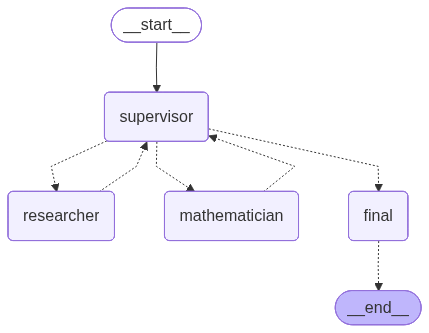

In [212]:
# Step 8 : Graph Building 


builder = StateGraph(SupervisorState)


# Node Addition
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("mathematician", math_node)
builder.add_node("final", final_node)


# Edge

builder.add_edge(START, "supervisor" )


#app 

app = builder.compile()
app 





In [206]:
initial_state = {'query': "What is 10+20? and what is the current situation of westbengal in the term of political aspect", 'history':[]}

In [213]:
app_result=app.invoke(initial_state)

🕴️Supervior - > Goto researcher | Resason The query has two parts: a simple arithmetic calculation and a request for the current political situation in West Bengal. Since the calculation is straightforward, the mathematician can handle it after we gather updated information about West Bengal's political situation. Therefore, the researcher should first gather recent and relevant information about West Bengal's political scenario.
🔎 Researcher Is working
🕴️Supervior - > Goto mathematician | Resason The researcher has provided sufficient and up-to-date information about the current political situation in West Bengal. The only remaining part of the original query is a simple arithmetic calculation (10+20), which the mathematician can handle efficiently. Therefore, the next step is to assign the mathematician to perform the calculation.
📱 Mathametician is Working
🕴️Supervior - > Goto final | Resason The researcher has provided comprehensive and current information about the political situa

In [220]:
(app_result['final_answer'])

"10 + 20 equals 30.\n\nAs of 2026, West Bengal's political landscape has shifted significantly with the Bharatiya Janata Party (BJP) winning the state legislative assembly election, ending the 15-year rule of the All India Trinamool Congress (AITC). The BJP secured an absolute majority with 208 seats, and Suvendu Adhikari became the Chief Minister. This marks the beginning of BJP governance in West Bengal, replacing the previous Trinamool Congress administration."

# Using Supervisor module

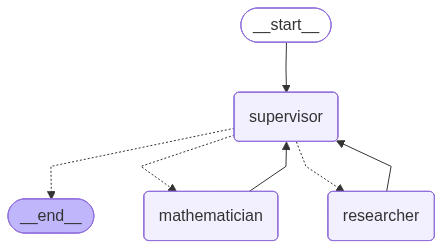

In [202]:
math_agent = create_agent(model=base_llm, tools=[calculate], 
                          name='mathematician', 
                          system_prompt="You Solve Math Problem using calculate tool")




research_agent = create_agent(model=base_llm, tools=[web_search], 
                          name='researcher', 
                          system_prompt="You do search in web using web_search tool")



supervisor_agnet = create_supervisor(
    model=base_llm,
    agents=[math_agent, research_agent], 
    prompt=("""You are a supervisor managing 2 workers "researcher" & 'mathematician,
            "Route the query correctly to the required agent, use mathematcian for math problems and for factual/current volatile infomartion use the researcher"
            """)
)

app=supervisor_agnet.compile()
app

app.invoke(initial_state)

In [191]:
initial_state1={'messages':[{'role': 'user', 'content': initial_state['query']}]}
initial_state1

{'messages': [{'role': 'user',
   'content': 'What is 10+20? and what is the current situation of westbengal in the term of political aspect'}]}

In [203]:
result=app.invoke({'messages':[{'role': 'user', 'content': "What is the current situation of westbengal politics and what is 912*2"}]})

for m in result['messages']:
    m.pretty_print()


================================ Human Message =================================

What is the current situation of westbengal politics and what is 912*2
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_researcher (call_5abslKURV29Lcah2YgFEk31d)
 Call ID: call_5abslKURV29Lcah2YgFEk31d
  Args:
================================= Tool Message =================================
Name: transfer_to_researcher

Successfully transferred to researcher
================================== Ai Message ==================================
Name: researcher

The current political situation in West Bengal as of 2024 shows a year marked by protests and electoral status quo. Despite protests over incidents like the rape and murder of a doctor at R.G. Kar Medical College and other agitations, the ruling Trinamool Congress maintained its electoral dominance. However, in a key state election in 2026, the Bharatiya Janata Party (BJP) took co

In [169]:
initial_state

{'query': 'What is 10+20? and what is the current situation of westbengal in the term of political aspect',
 'history': []}

In [183]:
result = app.invoke({
    "messages": [{"role": "user", "content": "What is 23847 * 9384 - 1029? and tell me about West Bengal politics"}]
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 23847 * 9384 - 1029? and tell me about West Bengal politics
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_mathematician (call_gTCj7GPEIIPAeJ7oPkWuFEde)
 Call ID: call_gTCj7GPEIIPAeJ7oPkWuFEde
  Args:
================================= Tool Message =================================
Name: transfer_to_mathematician

Successfully transferred to mathematician
================================== Ai Message ==================================
Name: mathematician

The result of the expression 23847 * 9384 - 1029 is 223,779,219.

Regarding West Bengal politics, it is a dynamic and complex political landscape in the Indian state of West Bengal. The state has a rich history of political activism and has been a stronghold of various political parties over the years. The major political parties in West Bengal include the All India Trina